# Clean Retrieval Notebook

This version keeps only the retrieval setups for:

1. **BM25**
2. **Keyword**
3. **Dense MiniLM - plain / old-style text** (using old cached embeddings first)
4. **Dense MiniLM - rich text** (fresh indexing from the richer text builder)
5. **Dense BGE - rich text**

It includes:

- **Single-tool evaluation**
- **Multi-tool evaluation** with **any / exact-set / set-recall** metrics
- **Scalability evaluation** across the smaller toolsets for **all 5 configs**


In [ ]:
!pip install -q rank-bm25 faiss-cpu sentence-transformers pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 85.9 MB/s eta 0:00:00


In [ ]:

# Imports + paths + config

import json
import pickle
import re
import time
from pathlib import Path
from typing import Optional, List, Dict, Any

import numpy as np
import pandas as pd
import faiss
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

#Base paths 
DRIVE_DIR = Path("/content/drive/MyDrive/MCP_Research")
REGISTRY_DIR = DRIVE_DIR

INDEX_DIR = DRIVE_DIR / "indices_clean"
INDEX_DIR.mkdir(parents=True, exist_ok=True)

SCALABILITY_DIR = DRIVE_DIR / "scalability_single_tool_eval"
SCALABILITY_INDEX_DIR = DRIVE_DIR / "indices_scalability_clean"
SCALABILITY_INDEX_DIR.mkdir(parents=True, exist_ok=True)

# Registry / GT files
MAIN_REGISTRY_FILE = "sealtools_mcp_registry.json"
SINGLE_GT_FILE = "gt_sealtools_single.jsonl"
MULTI_GT_FILE = "gt_sealtools_multi.jsonl"

SCALABILITY_REGISTRY_FILES = {
    "300": SCALABILITY_DIR / "sealtools_registry_300.json",
    "1000": SCALABILITY_DIR / "sealtools_registry_1000.json",
    "original": SCALABILITY_DIR / "sealtools_registry_original.json",
}

SCALABILITY_GT_PATH = SCALABILITY_DIR / "single_tool_traced_queries.jsonl"

# Retrieval config
TOP_K_VALUES = [1, 3, 5, 10]
DEFAULT_TOP_K = 10

MINILM_MODEL = "all-MiniLM-L6-v2"
BGE_MODEL = "BAAI/bge-base-en-v1.5"

# Dense plain / old-style config:
# This notebook will FIRST try to load one of these legacy cache names.
# If none exist, it will build and save a new plain-text cache under the first name.
OLD_PLAIN_DENSE_CACHE_CANDIDATES = [
    "sealtools_plain_old",
    "sealtools_plain",
    "sealtools_old_dense",
    "sealtools",
]

# Rich-text fresh names
RICH_MINILM_INDEX_NAME = "sealtools_rich_minilm_fresh"
RICH_BGE_INDEX_NAME = "sealtools_rich_bge"

print("✅ Setup complete")
print("DRIVE_DIR:", DRIVE_DIR)
print("INDEX_DIR:", INDEX_DIR)
print("SCALABILITY_INDEX_DIR:", SCALABILITY_INDEX_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete
DRIVE_DIR: /content/drive/MyDrive/MCP_Research
INDEX_DIR: /content/drive/MyDrive/MCP_Research/indices_clean
SCALABILITY_INDEX_DIR: /content/drive/MyDrive/MCP_Research/indices_scalability_clean


In [ ]:

# Text builders

def build_dense_plain_text(tool: dict) -> str:
    """Old / plain dense text: only name + description."""
    name = tool.get("name", "")
    desc = tool.get("description", "")
    return f"Tool: {name} | Description: {desc}".strip()


def build_dense_rich_text(tool: dict) -> str:
    """New richer dense text: name + description + domain + params + required fields."""
    schema = tool.get("inputSchema", {}) or {}
    props = schema.get("properties", {}) or {}
    required = schema.get("required", []) or []

    param_parts = []
    for pname, pinfo in props.items():
        ptype = pinfo.get("type", "")
        pdesc = pinfo.get("description", "")
        param_parts.append(f"{pname} ({ptype}): {pdesc}".strip())

    domain = tool.get("domain", "general")
    return " | ".join([
        f"Tool: {tool.get('name', '')}",
        f"Description: {tool.get('description', '')}",
        f"Domain: {domain}",
        f"Parameters: {'; '.join(param_parts)}",
        f"Required: {', '.join(required)}",
    ]).strip()


def build_bm25_text(tool: dict) -> str:
    """Lexical-heavy text for BM25 / keyword baselines."""
    schema = tool.get("inputSchema", {}) or {}
    props = schema.get("properties", {}) or {}
    required = schema.get("required", []) or []

    name = tool.get("name", "")
    desc = tool.get("description", "")
    domain = tool.get("domain", "general")

    return " ".join([
        name,
        name.replace("_", " "),
        desc,
        domain,
        " ".join(props.keys()),
        " ".join(required),
        desc,
    ]).strip()


def get_text_builder(text_mode: str):
    if text_mode == "plain":
        return build_dense_plain_text
    if text_mode == "rich":
        return build_dense_rich_text
    raise ValueError(f"Unsupported text_mode: {text_mode}")


print("✅ Text builders ready")


✅ Text builders ready


In [ ]:

# Data loading helpers

def load_registry(path_or_name) -> list:
    path = Path(path_or_name)
    if not path.is_absolute():
        path = REGISTRY_DIR / path

    if not path.exists():
        raise FileNotFoundError(f"Registry not found: {path}")

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    tools = data["tools"] if isinstance(data, dict) and "tools" in data else data
    print(f"✅ Loaded {len(tools)} tools from {path.name}")
    return tools


def load_jsonl(path_or_name) -> list:
    path = Path(path_or_name)
    if not path.is_absolute():
        path = DRIVE_DIR / path

    if not path.exists():
        raise FileNotFoundError(f"JSONL file not found: {path}")

    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

    print(f"✅ Loaded {len(rows)} rows from {path.name}")
    return rows


def get_expected_tool(sample: dict) -> str:
    if sample.get("expected_tool"):
        return sample["expected_tool"]
    chain = sample.get("tool_chain") or []
    return chain[0] if chain else ""


main_tools = load_registry(MAIN_REGISTRY_FILE)
gt_single = load_jsonl(SINGLE_GT_FILE)
gt_multi = load_jsonl(MULTI_GT_FILE)


✅ Loaded 4076 tools from sealtools_mcp_registry.json
✅ Loaded 294 rows from gt_sealtools_single.jsonl
✅ Loaded 1060 rows from gt_sealtools_multi.jsonl


In [ ]:

# Retrievers

class DenseRetriever:
    def __init__(self, tools: list, model_name: str, text_mode: str,
                 index_dir: Path, emb_dir: Optional[Path] = None):
        self.tools = tools
        self.model_name = model_name
        self.text_mode = text_mode
        self.index_dir = Path(index_dir)
        self.emb_dir = Path(emb_dir) if emb_dir is not None else Path(index_dir)

        self.index_dir.mkdir(parents=True, exist_ok=True)
        self.emb_dir.mkdir(parents=True, exist_ok=True)

        self.model = None
        self.index = None
        self.texts = []
        self.name_to_tool = {t["name"]: t for t in tools}

    def _safe_model_name(self):
        return re.sub(r"[^a-zA-Z0-9._-]+", "_", self.model_name)

    def _cache_paths(self, base_name: str):
        safe_model = self._safe_model_name()
        index_path = self.index_dir / f"{base_name}_{safe_model}_faiss.index"
        emb_path = self.emb_dir / f"{base_name}_{safe_model}_embeddings.npy"
        meta_path = self.index_dir / f"{base_name}_{safe_model}_dense_meta.pkl"
        return index_path, emb_path, meta_path

    def _legacy_plain_cache_paths(self, base_name: str):
        # Compatibility path for old non-model-scoped caches
        index_path = self.index_dir / f"{base_name}_faiss.index"
        emb_path = DRIVE_DIR / f"{base_name}_embeddings.npy"
        meta_path = self.index_dir / f"{base_name}_dense_meta.pkl"
        return index_path, emb_path, meta_path

    def _set_texts(self):
        builder = get_text_builder(self.text_mode)
        self.texts = [builder(t) for t in self.tools]

    def _load_if_exists(self, index_path: Path, meta_path: Path) -> bool:
        if index_path.exists() and meta_path.exists():
            self.index = faiss.read_index(str(index_path))
            with open(meta_path, "rb") as f:
                meta = pickle.load(f)
            self.texts = meta.get("texts", self.texts)
            print(f"✅ Loaded dense index: {index_path.name} | vectors={self.index.ntotal}")
            return True
        return False

    def build_index(self, index_name: str, batch_size: int = 64,
                    rebuild: bool = False,
                    legacy_cache_candidates: Optional[list] = None) -> None:
        self._set_texts()

        print(f"Loading embedding model: {self.model_name}")
        self.model = SentenceTransformer(self.model_name)

        # 1) Try explicit legacy candidates first when asked
        if not rebuild and legacy_cache_candidates:
            for legacy_name in legacy_cache_candidates:
                idx_path, emb_path, meta_path = self._legacy_plain_cache_paths(legacy_name)
                if self._load_if_exists(idx_path, meta_path):
                    print(f"   ↳ reused legacy cache name: {legacy_name}")
                    return

        # 2) Try the current model-scoped cache
        index_path, emb_path, meta_path = self._cache_paths(index_name)
        if not rebuild and self._load_if_exists(index_path, meta_path):
            return

        # 3) Build fresh
        print(f"Embedding {len(self.texts)} tools from scratch...")
        t0 = time.time()
        embeddings = self.model.encode(
            self.texts,
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")
        print(f"   Done in {time.time()-t0:.1f}s | shape={embeddings.shape}")

        np.save(str(emb_path), embeddings)

        dim = embeddings.shape[1]
        if len(self.tools) > 1000:
            index = faiss.IndexHNSWFlat(dim, 32)
            index.hnsw.efConstruction = 200
            index.hnsw.efSearch = 64
            index_type = "HNSW"
        else:
            index = faiss.IndexFlatIP(dim)
            index_type = "FlatIP"

        index.add(embeddings)
        faiss.write_index(index, str(index_path))
        self.index = index

        with open(meta_path, "wb") as f:
            pickle.dump({
                "texts": self.texts,
                "model_name": self.model_name,
                "text_mode": self.text_mode,
                "tool_names": [t["name"] for t in self.tools],
            }, f)

        print(f"✅ Saved dense index  → {index_path}")
        print(f"✅ Saved embeddings   → {emb_path}")
        print(f"✅ Index type         → {index_type}")

    def search(self, query: str, k: int = DEFAULT_TOP_K) -> list:
        if self.index is None:
            raise RuntimeError("Dense index has not been built yet.")

        q = self.model.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")

        scores, idxs = self.index.search(q, k)
        results = []
        for score, idx in zip(scores[0], idxs[0]):
            if idx < 0 or idx >= len(self.tools):
                continue
            tool = self.tools[idx]
            results.append({
                "name": tool["name"],
                "score": float(score),
                "description": tool.get("description", ""),
            })
        return results


class BM25Retriever:
    def __init__(self, tools: list, index_dir: Path):
        self.tools = tools
        self.index_dir = Path(index_dir)
        self.index_dir.mkdir(parents=True, exist_ok=True)

        self.bm25 = None
        self.corpus_tokens = []

    @staticmethod
    def _tokenize(text: str) -> list:
        return re.sub(r"[^a-zA-Z0-9]", " ", text.lower()).split()

    def build_index(self, index_name: str) -> None:
        cache_path = self.index_dir / f"{index_name}_bm25.pkl"

        if cache_path.exists():
            with open(cache_path, "rb") as f:
                data = pickle.load(f)
            self.bm25 = data["bm25"]
            self.corpus_tokens = data["corpus_tokens"]
            print(f"✅ Loaded BM25 cache: {cache_path.name}")
            return

        corpus = [build_bm25_text(t) for t in self.tools]
        self.corpus_tokens = [self._tokenize(x) for x in corpus]
        self.bm25 = BM25Okapi(self.corpus_tokens)

        with open(cache_path, "wb") as f:
            pickle.dump({
                "bm25": self.bm25,
                "corpus_tokens": self.corpus_tokens,
            }, f)

        print(f"✅ Saved BM25 cache: {cache_path}")

    def search(self, query: str, k: int = DEFAULT_TOP_K) -> list:
        q_tokens = self._tokenize(query)
        scores = self.bm25.get_scores(q_tokens)
        order = np.argsort(scores)[::-1][:k]
        return [
            {
                "name": self.tools[i]["name"],
                "score": float(scores[i]),
                "description": self.tools[i].get("description", ""),
            }
            for i in order
        ]


class KeywordRetriever:
    def __init__(self, tools: list):
        self.tools = tools
        self.tool_token_sets = []

    @staticmethod
    def _tokenize(text: str) -> set:
        return set(re.sub(r"[^a-zA-Z0-9]", " ", text.lower()).split())

    def build_index(self) -> None:
        corpus = [build_bm25_text(t) for t in self.tools]
        self.tool_token_sets = [self._tokenize(x) for x in corpus]
        print(f"✅ Built keyword index over {len(self.tool_token_sets)} tools")

    def search(self, query: str, k: int = DEFAULT_TOP_K) -> list:
        q_tokens = self._tokenize(query)
        scores = []
        for tokset in self.tool_token_sets:
            overlap = len(q_tokens & tokset)
            denom = max(len(q_tokens), 1)
            scores.append(overlap / denom)

        order = np.argsort(scores)[::-1][:k]
        return [
            {
                "name": self.tools[i]["name"],
                "score": float(scores[i]),
                "description": self.tools[i].get("description", ""),
            }
            for i in order
        ]


print("✅ Retriever classes ready")


✅ Retriever classes ready


In [ ]:

# Metrics + evaluation helpers

def recall_at_k(results: list, expected_tool: str, k: int) -> float:
    names = [r["name"] for r in results[:k]]
    return 1.0 if expected_tool in names else 0.0


def mrr_at_k(results: list, expected_tool: str, k: int) -> float:
    for rank, r in enumerate(results[:k], start=1):
        if r["name"] == expected_tool:
            return 1.0 / rank
    return 0.0


def recall_any_at_k(results: list, tool_chain: list, k: int) -> float:
    retrieved = [r["name"] for r in results[:k]]
    return 1.0 if any(t in retrieved for t in tool_chain) else 0.0


def recall_set_at_k(results: list, tool_chain: list, k: int) -> float:
    retrieved = set(r["name"] for r in results[:k])
    gt = set(tool_chain)
    return len(retrieved & gt) / len(gt) if gt else 0.0


def exact_match_at_k(results: list, tool_chain: list, k: int) -> float:
    retrieved = set(r["name"] for r in results[:k])
    gt = set(tool_chain)
    return 1.0 if gt.issubset(retrieved) else 0.0


def evaluate_single_tool(retriever, ground_truth: list, k_values=TOP_K_VALUES, label="retriever") -> dict:
    max_k = max(k_values)
    recall_hits = {k: 0 for k in k_values}
    mrr_sums = {k: 0.0 for k in k_values}
    latencies_ms = []

    for sample in tqdm(ground_truth, desc=f"Single-tool eval [{label}]"):
        query = sample["query"]
        expected = get_expected_tool(sample)

        t0 = time.time()
        results = retriever.search(query, k=max_k)
        latencies_ms.append((time.time() - t0) * 1000)

        for k in k_values:
            recall_hits[k] += recall_at_k(results, expected, k)
            mrr_sums[k] += mrr_at_k(results, expected, k)

    n = max(len(ground_truth), 1)
    out = {"label": label, "n": len(ground_truth), "avg_latency_ms": round(float(np.mean(latencies_ms)), 3)}
    for k in k_values:
        out[f"recall@{k}"] = round(recall_hits[k] / n, 4)
        out[f"mrr@{k}"] = round(mrr_sums[k] / n, 4)
    return out


def evaluate_multi_tool(retriever, dataset: list, k_values=TOP_K_VALUES, label="retriever") -> dict:
    metrics = {f"any@{k}": [] for k in k_values}
    metrics.update({f"set_recall@{k}": [] for k in k_values})
    metrics.update({f"exact@{k}": [] for k in k_values})
    latencies_ms = []

    for sample in tqdm(dataset, desc=f"Multi-tool eval [{label}]"):
        query = sample["query"]
        tool_chain = sample.get("tool_chain", [])

        t0 = time.time()
        results = retriever.search(query, k=max(k_values))
        latencies_ms.append((time.time() - t0) * 1000)

        for k in k_values:
            metrics[f"any@{k}"].append(recall_any_at_k(results, tool_chain, k))
            metrics[f"set_recall@{k}"].append(recall_set_at_k(results, tool_chain, k))
            metrics[f"exact@{k}"].append(exact_match_at_k(results, tool_chain, k))

    out = {"label": label, "n": len(dataset), "avg_latency_ms": round(float(np.mean(latencies_ms)), 3)}
    for key, values in metrics.items():
        out[key] = round(float(np.mean(values)) if values else 0.0, 4)
    return out


def to_df(rows: list) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    if "label" in df.columns:
        front = ["label"] + [c for c in df.columns if c != "label"]
        df = df[front]
    return df


print("✅ Metrics ready")


✅ Metrics ready


In [ ]:

# Build the 5 retrievers on the main registry

configs_main = {}

# 1) BM25
bm25 = BM25Retriever(main_tools, index_dir=INDEX_DIR)
bm25.build_index(index_name="sealtools_main")
configs_main["BM25"] = bm25

# 2) Keyword
kw = KeywordRetriever(main_tools)
kw.build_index()
configs_main["Keyword"] = kw

# 3) Dense MiniLM plain / old-style
dense_plain_old = DenseRetriever(
    main_tools,
    model_name=MINILM_MODEL,
    text_mode="plain",
    index_dir=INDEX_DIR,
    emb_dir=DRIVE_DIR,
)
dense_plain_old.build_index(
    index_name=OLD_PLAIN_DENSE_CACHE_CANDIDATES[0],
    rebuild=False,
    legacy_cache_candidates=OLD_PLAIN_DENSE_CACHE_CANDIDATES,
)
configs_main["Dense MiniLM Plain (old cache if found)"] = dense_plain_old

# 4) Dense MiniLM rich / fresh
dense_rich_minilm = DenseRetriever(
    main_tools,
    model_name=MINILM_MODEL,
    text_mode="rich",
    index_dir=INDEX_DIR,
    emb_dir=DRIVE_DIR,
)
dense_rich_minilm.build_index(
    index_name=RICH_MINILM_INDEX_NAME,
    rebuild=True,
)
configs_main["Dense MiniLM Rich (fresh)"] = dense_rich_minilm

# 5) Dense BGE rich
dense_rich_bge = DenseRetriever(
    main_tools,
    model_name=BGE_MODEL,
    text_mode="rich",
    index_dir=INDEX_DIR,
    emb_dir=DRIVE_DIR,
)
dense_rich_bge.build_index(
    index_name=RICH_BGE_INDEX_NAME,
    rebuild=False,
)
configs_main["Dense BGE Rich"] = dense_rich_bge

print("\n✅ Built all 5 requested retrievers")
print(list(configs_main.keys()))


✅ Saved BM25 cache: /content/drive/MyDrive/MCP_Research/indices_clean/sealtools_main_bm25.pkl
✅ Built keyword index over 4076 tools
Loading embedding model: all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 4076 tools from scratch...


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

   Done in 25.0s | shape=(4076, 768)
✅ Saved dense index  → /content/drive/MyDrive/MCP_Research/indices_clean/sealtools_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
✅ Saved embeddings   → /content/drive/MyDrive/MCP_Research/sealtools_rich_bge_BAAI_bge-base-en-v1.5_embeddings.npy
✅ Index type         → HNSW

✅ Built all 5 requested retrievers
['BM25', 'Keyword', 'Dense MiniLM Plain (old cache if found)', 'Dense MiniLM Rich (fresh)', 'Dense BGE Rich']


## Single-tool evaluation

In [ ]:

single_results = []

for label, retriever in configs_main.items():
    res = evaluate_single_tool(retriever, gt_single, label=label)
    single_results.append(res)

single_df = to_df(single_results)
single_df = single_df.sort_values("label").reset_index(drop=True)
display(single_df)

single_out_csv = DRIVE_DIR / "clean_single_tool_results_5configs.csv"
single_out_json = DRIVE_DIR / "clean_single_tool_results_5configs.json"

single_df.to_csv(single_out_csv, index=False)
with open(single_out_json, "w", encoding="utf-8") as f:
    json.dump(single_results, f, indent=2)

print("Saved:", single_out_csv)
print("Saved:", single_out_json)


Single-tool eval [BM25]:   0%|          | 0/294 [00:00<?, ?it/s]

Single-tool eval [Keyword]:   0%|          | 0/294 [00:00<?, ?it/s]

Single-tool eval [Dense MiniLM Plain (old cache if found)]:   0%|          | 0/294 [00:00<?, ?it/s]

Single-tool eval [Dense MiniLM Rich (fresh)]:   0%|          | 0/294 [00:00<?, ?it/s]

Single-tool eval [Dense BGE Rich]:   0%|          | 0/294 [00:00<?, ?it/s]

,label,n,avg_latency_ms,recall@1,mrr@1,recall@3,mrr@3,recall@5,mrr@5,recall@10,mrr@10
0,BM25,294,13.223,0.8299,0.8299,0.9218,0.8724,0.9456,0.8779,0.9558,0.8791
1,Dense BGE Rich,294,11.011,0.8946,0.8946,0.9592,0.9252,0.9728,0.9286,0.9864,0.9302
2,Dense MiniLM Plain (old cache if found),294,7.418,0.6905,0.6905,0.8401,0.7579,0.8912,0.7695,0.9252,0.7739
3,Dense MiniLM Rich (fresh),294,6.478,0.8095,0.8095,0.9184,0.8594,0.9354,0.8635,0.9592,0.8669
4,Keyword,294,2.823,0.5204,0.5204,0.6497,0.5788,0.6837,0.5859,0.7075,0.5892


Saved: /content/drive/MyDrive/MCP_Research/clean_single_tool_results_5configs.csv
Saved: /content/drive/MyDrive/MCP_Research/clean_single_tool_results_5configs.json


## Multi-tool evaluation

Metrics used:

- **any@k**
- **set_recall@k**
- **exact@k**


In [ ]:

multi_results = []

for label, retriever in configs_main.items():
    res = evaluate_multi_tool(retriever, gt_multi, label=label)
    multi_results.append(res)

multi_df = to_df(multi_results)
multi_df = multi_df.sort_values("label").reset_index(drop=True)
display(multi_df)

multi_out_csv = DRIVE_DIR / "clean_multi_tool_results_5configs.csv"
multi_out_json = DRIVE_DIR / "clean_multi_tool_results_5configs.json"

multi_df.to_csv(multi_out_csv, index=False)
with open(multi_out_json, "w", encoding="utf-8") as f:
    json.dump(multi_results, f, indent=2)

print("Saved:", multi_out_csv)
print("Saved:", multi_out_json)


Multi-tool eval [BM25]:   0%|          | 0/1060 [00:00<?, ?it/s]

Multi-tool eval [Keyword]:   0%|          | 0/1060 [00:00<?, ?it/s]

Multi-tool eval [Dense MiniLM Plain (old cache if found)]:   0%|          | 0/1060 [00:00<?, ?it/s]

Multi-tool eval [Dense MiniLM Rich (fresh)]:   0%|          | 0/1060 [00:00<?, ?it/s]

Multi-tool eval [Dense BGE Rich]:   0%|          | 0/1060 [00:00<?, ?it/s]

,label,n,avg_latency_ms,any@1,any@3,any@5,any@10,set_recall@1,set_recall@3,set_recall@5,set_recall@10,exact@1,exact@3,exact@5,exact@10
0,BM25,1060,49.895,0.8123,0.9528,0.9783,0.9925,0.2571,0.5432,0.6600,0.7773,0.0,0.1009,0.2519,0.4528
1,Dense BGE Rich,1060,13.007,0.7906,0.9377,0.9679,0.9887,0.2510,0.4247,0.5090,0.5985,0.0,0.0274,0.0906,0.1821
2,Dense MiniLM Plain (old cache if found),1060,7.109,0.6802,0.8840,0.9368,0.9774,0.2169,0.3756,0.4509,0.5609,0.0,0.0198,0.0547,0.1415
3,Dense MiniLM Rich (fresh),1060,7.885,0.7632,0.9170,0.9575,0.9840,0.2428,0.4051,0.4817,0.5817,0.0,0.0236,0.0698,0.1604
4,Keyword,1060,4.120,0.6632,0.8302,0.8858,0.9292,0.2093,0.3831,0.4602,0.5518,0.0,0.0274,0.0811,0.1594


Saved: /content/drive/MyDrive/MCP_Research/clean_multi_tool_results_5configs.csv
Saved: /content/drive/MyDrive/MCP_Research/clean_multi_tool_results_5configs.json


## Scalability test on all 5 configs

This runs the same single-tool retrieval evaluation over the smaller toolsets.


In [ ]:

# Scalability helpers

def build_scalability_configs(tools: list, registry_label: str):
    configs = {}

    # BM25
    bm25 = BM25Retriever(tools, index_dir=SCALABILITY_INDEX_DIR)
    bm25.build_index(index_name=f"scal_{registry_label}")
    configs["BM25"] = bm25

    # Keyword
    kw = KeywordRetriever(tools)
    kw.build_index()
    configs["Keyword"] = kw

    # Dense MiniLM plain
    dense_plain = DenseRetriever(
        tools,
        model_name=MINILM_MODEL,
        text_mode="plain",
        index_dir=SCALABILITY_INDEX_DIR,
        emb_dir=SCALABILITY_INDEX_DIR,
    )
    dense_plain.build_index(
        index_name=f"scal_{registry_label}_plain_minilm",
        rebuild=False,
    )
    configs["Dense MiniLM Plain"] = dense_plain

    # Dense MiniLM rich
    dense_rich = DenseRetriever(
        tools,
        model_name=MINILM_MODEL,
        text_mode="rich",
        index_dir=SCALABILITY_INDEX_DIR,
        emb_dir=SCALABILITY_INDEX_DIR,
    )
    dense_rich.build_index(
        index_name=f"scal_{registry_label}_rich_minilm",
        rebuild=False,
    )
    configs["Dense MiniLM Rich"] = dense_rich

    # Dense BGE rich
    dense_bge = DenseRetriever(
        tools,
        model_name=BGE_MODEL,
        text_mode="rich",
        index_dir=SCALABILITY_INDEX_DIR,
        emb_dir=SCALABILITY_INDEX_DIR,
    )
    dense_bge.build_index(
        index_name=f"scal_{registry_label}_rich_bge",
        rebuild=False,
    )
    configs["Dense BGE Rich"] = dense_bge

    return configs


gt_scalability = load_jsonl(SCALABILITY_GT_PATH)

scalability_rows = []

for registry_label, registry_path in SCALABILITY_REGISTRY_FILES.items():
    print("\n" + "=" * 80)
    print(f"SCALABILITY REGISTRY: {registry_label}")
    print("=" * 80)

    tools = load_registry(registry_path)
    cfgs = build_scalability_configs(tools, registry_label=registry_label)

    for cfg_label, retriever in cfgs.items():
        res = evaluate_single_tool(
            retriever,
            gt_scalability,
            label=cfg_label,
        )
        res["registry"] = registry_label
        scalability_rows.append(res)

scalability_df = pd.DataFrame(scalability_rows)
ordered_cols = ["registry", "label"] + [c for c in scalability_df.columns if c not in ["registry", "label"]]
scalability_df = scalability_df[ordered_cols].sort_values(["registry", "label"]).reset_index(drop=True)

display(scalability_df)

scal_csv = SCALABILITY_DIR / "clean_scalability_results_5configs.csv"
scal_json = SCALABILITY_DIR / "clean_scalability_results_5configs.json"

scalability_df.to_csv(scal_csv, index=False)
with open(scal_json, "w", encoding="utf-8") as f:
    json.dump(scalability_rows, f, indent=2)

print("Saved:", scal_csv)
print("Saved:", scal_json)


✅ Loaded 294 rows from single_tool_traced_queries.jsonl

SCALABILITY REGISTRY: 300
✅ Loaded 300 tools from sealtools_registry_300.json
✅ Saved BM25 cache: /content/drive/MyDrive/MCP_Research/indices_scalability_clean/scal_300_bm25.pkl
✅ Built keyword index over 300 tools
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 300 tools from scratch...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Single-tool eval [Dense MiniLM Plain]:   0%|          | 0/294 [00:00<?, ?it/s]

Single-tool eval [Dense MiniLM Rich]:   0%|          | 0/294 [00:00<?, ?it/s]

Single-tool eval [Dense BGE Rich]:   0%|          | 0/294 [00:00<?, ?it/s]

,registry,label,n,avg_latency_ms,recall@1,mrr@1,recall@3,mrr@3,recall@5,mrr@5,recall@10,mrr@10
0,1000,BM25,294,3.821,0.8912,0.8912,0.9422,0.9155,0.9558,0.9188,0.9694,0.9205
1,1000,Dense BGE Rich,294,11.281,0.9558,0.9558,0.9830,0.9683,0.9898,0.9700,0.9932,0.9703
2,1000,Dense MiniLM Plain,294,8.980,0.7891,0.7891,0.9082,0.8413,0.9320,0.8471,0.9524,0.8498
3,1000,Dense MiniLM Rich,294,6.722,0.9014,0.9014,0.9490,0.9246,0.9694,0.9294,0.9796,0.9305
4,1000,Keyword,294,1.157,0.6293,0.6293,0.7313,0.6735,0.7483,0.6774,0.7891,0.6825
5,300,BM25,294,0.821,0.9286,0.9286,0.9660,0.9450,0.9762,0.9472,0.9864,0.9485
6,300,Dense BGE Rich,294,11.124,0.9796,0.9796,0.9864,0.9830,1.0000,0.9861,1.0000,0.9861
7,300,Dense MiniLM Plain,294,6.748,0.8503,0.8503,0.9558,0.8957,0.9660,0.8981,0.9830,0.9004
8,300,Dense MiniLM Rich,294,6.571,0.9354,0.9354,0.9626,0.9490,0.9864,0.9543,0.9932,0.9554
9,300,Keyword,294,0.378,0.6973,0.6973,0.7823,0.7353,0.8129,0.7419,0.8639,0.7487


Saved: /content/drive/MyDrive/MCP_Research/scalability_single_tool_eval/clean_scalability_results_5configs.csv
Saved: /content/drive/MyDrive/MCP_Research/scalability_single_tool_eval/clean_scalability_results_5configs.json


## Optional sanity search

In [ ]:

test_query = "book a flight from London to New York"

for label, retriever in configs_main.items():
    res = retriever.search(test_query, k=5)
    print("\n" + "-" * 70)
    print(label)
    for i, r in enumerate(res, start=1):
        print(f"{i:>2}. {r['name']:<40s} score={r['score']:.4f}")



----------------------------------------------------------------------
BM25
 1. flightBooking                            score=16.8134
 2. borrowBook                               score=16.2884
 3. bookFlight                               score=16.2182
 4. addBook                                  score=16.0167
 5. removeBook                               score=15.9547

----------------------------------------------------------------------
Keyword
 1. addBook                                  score=0.5000
 2. checkoutBook                             score=0.3750
 3. interpret                                score=0.3750
 4. performFailover                          score=0.3750
 5. returnBook                               score=0.3750

----------------------------------------------------------------------
Dense MiniLM Plain (old cache if found)
 1. bookFlight                               score=1.0325
 2. flightBooking                            score=1.0570
 3. createAirline             

## Notes

- The **plain MiniLM** config is set to **try old cache names first** so it can reuse your old cached embedding/index if those files already exist.
- The **rich MiniLM** config is forced to **rebuild fresh** on the main registry.
- The **BGE rich** config uses rich text and its own model-specific cache.



In [ ]:
from pathlib import Path

idx_dir = DRIVE_DIR / "indices_scalability_clean"
for p in sorted(idx_dir.glob("*original*")):
    print(p.name)

scal_original_bm25.pkl
scal_original_plain_minilm_all-MiniLM-L6-v2_dense_meta.pkl
scal_original_plain_minilm_all-MiniLM-L6-v2_embeddings.npy
scal_original_plain_minilm_all-MiniLM-L6-v2_faiss.index
scal_original_rich_bge_BAAI_bge-base-en-v1.5_dense_meta.pkl
scal_original_rich_bge_BAAI_bge-base-en-v1.5_embeddings.npy
scal_original_rich_bge_BAAI_bge-base-en-v1.5_faiss.index
scal_original_rich_minilm_all-MiniLM-L6-v2_dense_meta.pkl
scal_original_rich_minilm_all-MiniLM-L6-v2_embeddings.npy
scal_original_rich_minilm_all-MiniLM-L6-v2_faiss.index


## Visualizations for Research Paper

### Single-Tool Evaluation Metrics (Recall@1 and MRR@1)

/tmp/ipykernel_1900/2293353796.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='recall@1', data=single_df_plot.sort_values('recall@1', ascending=False), ax=axes[0], palette='Blues_d')
/tmp/ipykernel_1900/2293353796.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='mrr@1', data=single_df_plot.sort_values('mrr@1', ascending=False), ax=axes[1], palette='Reds_d')


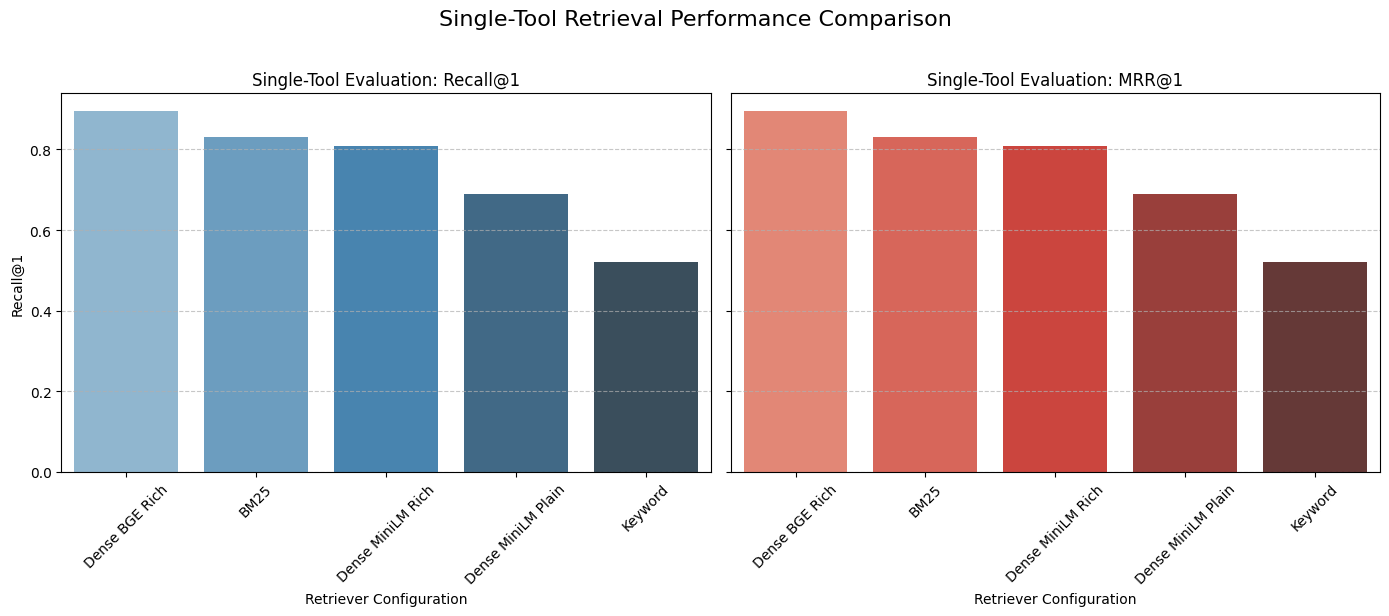

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the dataframe is correctly loaded if not already in context
# single_df = pd.read_csv(DRIVE_DIR / "clean_single_tool_results_5configs.csv") # Uncomment if running standalone

# Rename labels for cleaner visualization
single_df_plot = single_df.copy()
single_df_plot['label'] = single_df_plot['label'].replace({
    'Dense MiniLM Plain (old cache if found)': 'Dense MiniLM Plain',
    'Dense MiniLM Rich (fresh)': 'Dense MiniLM Rich'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(x='label', y='recall@1', data=single_df_plot.sort_values('recall@1', ascending=False), ax=axes[0], palette='Blues_d')
axes[0].set_title('Single-Tool Evaluation: Recall@1')
axes[0].set_xlabel('Retriever Configuration')
axes[0].set_ylabel('Recall@1')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='label', y='mrr@1', data=single_df_plot.sort_values('mrr@1', ascending=False), ax=axes[1], palette='Reds_d')
axes[1].set_title('Single-Tool Evaluation: MRR@1')
axes[1].set_xlabel('Retriever Configuration')
axes[1].set_ylabel('MRR@1')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Single-Tool Retrieval Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# You can save the figure if needed for a research paper
# fig.savefig(DRIVE_DIR / 'single_tool_eval_metrics.png', dpi=300, bbox_inches='tight')

### Multi-Tool Evaluation Metrics (Any@1, Set Recall@1, Exact@1)

/tmp/ipykernel_1900/2367448983.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y=metric, data=multi_df_plot.sort_values(metric, ascending=False), ax=axes[i], palette=palettes[i])
/tmp/ipykernel_1900/2367448983.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y=metric, data=multi_df_plot.sort_values(metric, ascending=False), ax=axes[i], palette=palettes[i])
/tmp/ipykernel_1900/2367448983.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y=metric, data=multi_df_plot.sort_values(metric, ascending=Fal

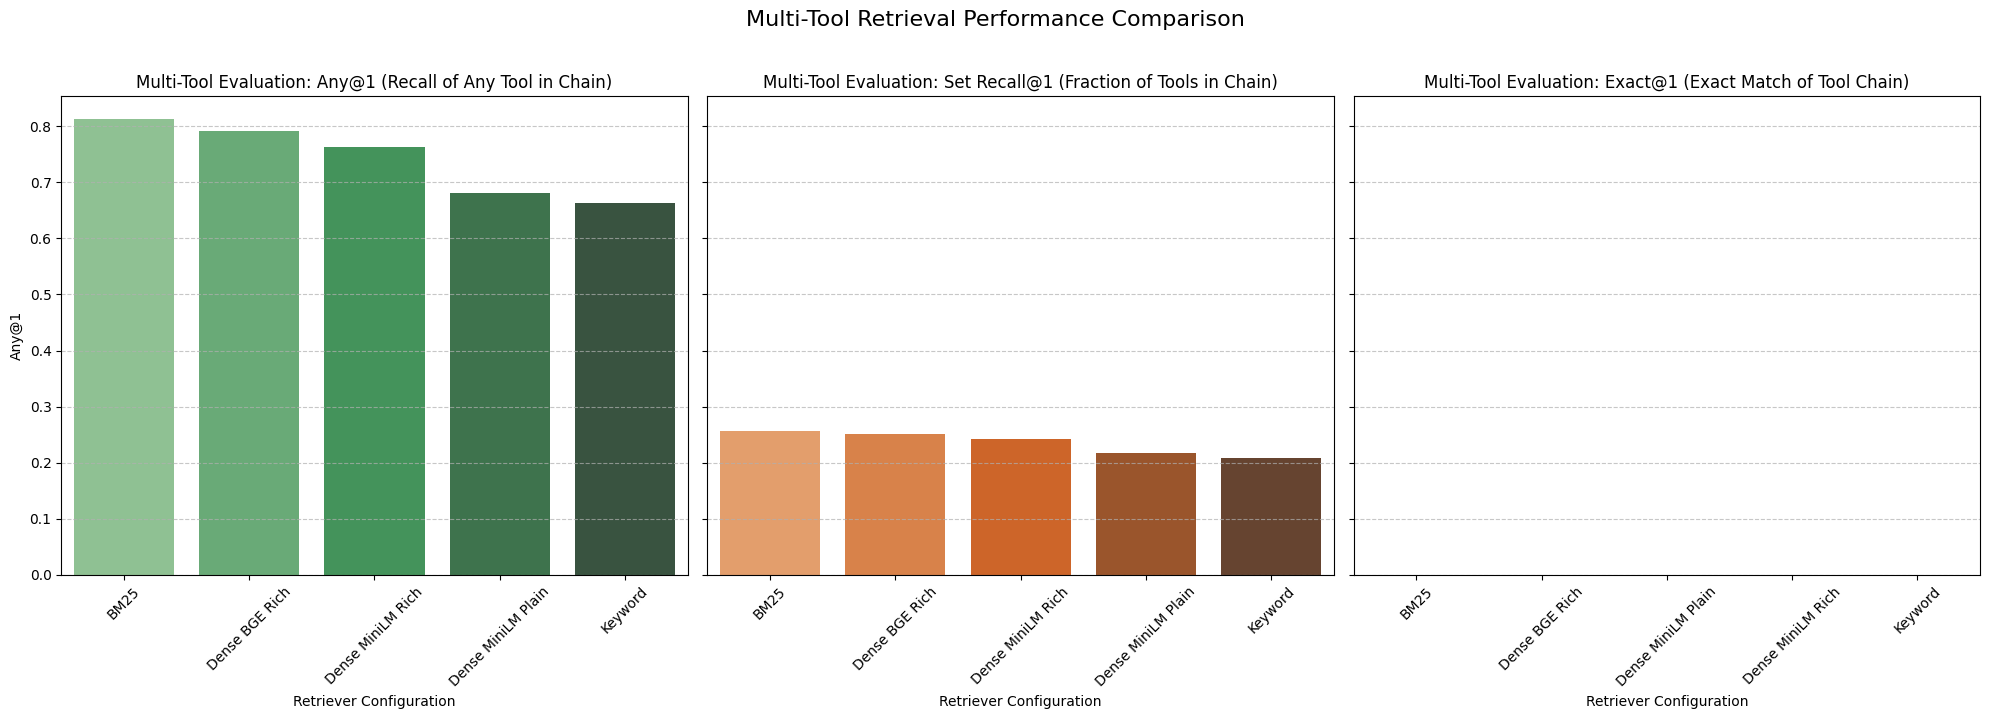

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the dataframe is correctly loaded if not already in context
# multi_df = pd.read_csv(DRIVE_DIR / "clean_multi_tool_results_5configs.csv") # Uncomment if running standalone

# Rename labels for cleaner visualization
multi_df_plot = multi_df.copy()
multi_df_plot['label'] = multi_df_plot['label'].replace({
    'Dense MiniLM Plain (old cache if found)': 'Dense MiniLM Plain',
    'Dense MiniLM Rich (fresh)': 'Dense MiniLM Rich'
})

metrics = ['any@1', 'set_recall@1', 'exact@1']
metric_titles = ['Any@1 (Recall of Any Tool in Chain)', 'Set Recall@1 (Fraction of Tools in Chain)', 'Exact@1 (Exact Match of Tool Chain)']
palettes = ['Greens_d', 'Oranges_d', 'Purples_d'] # Specific monochrome palettes

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for i, metric in enumerate(metrics):
    sns.barplot(x='label', y=metric, data=multi_df_plot.sort_values(metric, ascending=False), ax=axes[i], palette=palettes[i])
    axes[i].set_title(f'Multi-Tool Evaluation: {metric_titles[i]}')
    axes[i].set_xlabel('Retriever Configuration')
    axes[i].set_ylabel(metric.replace('_', ' ').title())
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Multi-Tool Retrieval Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# You can save the figure if needed for a research paper
# fig.savefig(DRIVE_DIR / 'multi_tool_eval_metrics.png', dpi=300, bbox_inches='tight')

### Scalability Evaluation (Recall@1 and MRR@1 across Registry Sizes)

/tmp/ipykernel_1900/4289065480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='recall@1', data=single_df.sort_values('recall@1', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_1900/4289065480.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='mrr@1', data=single_df.sort_values('mrr@1', ascending=False), ax=axes[1], palette='plasma')


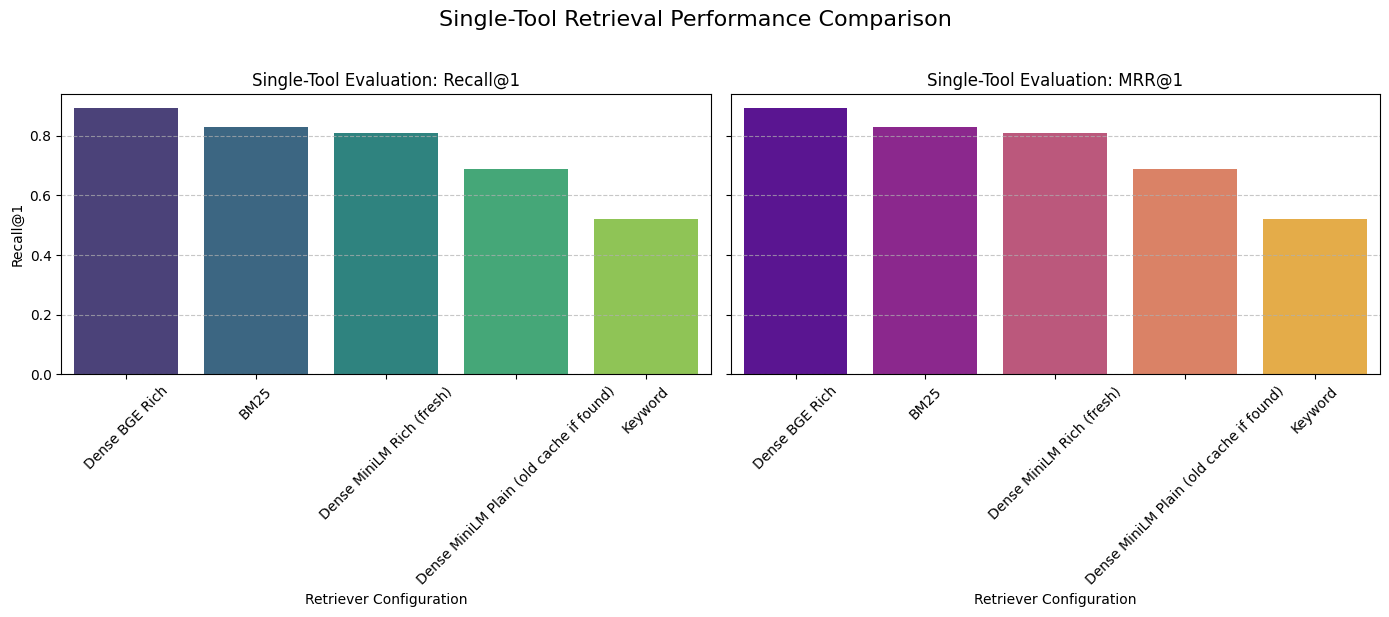

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the dataframe is correctly loaded if not already in context
# single_df = pd.read_csv(DRIVE_DIR / "clean_single_tool_results_5configs.csv") # Uncomment if running standalone

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(x='label', y='recall@1', data=single_df.sort_values('recall@1', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Single-Tool Evaluation: Recall@1')
axes[0].set_xlabel('Retriever Configuration')
axes[0].set_ylabel('Recall@1')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='label', y='mrr@1', data=single_df.sort_values('mrr@1', ascending=False), ax=axes[1], palette='plasma')
axes[1].set_title('Single-Tool Evaluation: MRR@1')
axes[1].set_xlabel('Retriever Configuration')
axes[1].set_ylabel('MRR@1')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Single-Tool Retrieval Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# You can save the figure if needed for a research paper
# fig.savefig(DRIVE_DIR / 'single_tool_eval_metrics.png', dpi=300, bbox_inches='tight')

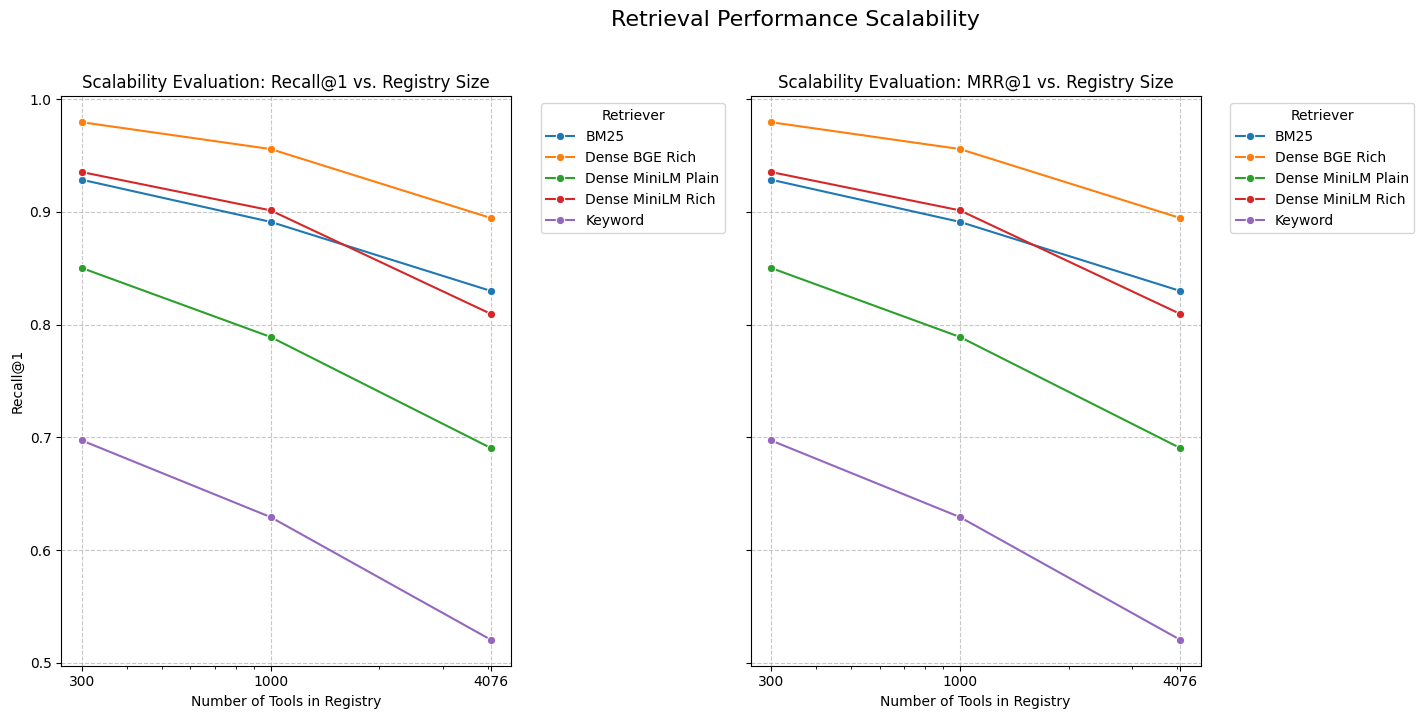

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the dataframe is correctly loaded if not already in context
# scalability_df = pd.read_csv(DRIVE_DIR / "clean_scalability_results_5configs.csv") # Uncomment if running standalone

# Rename labels for cleaner visualization
scalability_df_plot = scalability_df.copy()
scalability_df_plot['label'] = scalability_df_plot['label'].replace({
    'Dense MiniLM Plain (old cache if found)': 'Dense MiniLM Plain',
    'Dense MiniLM Rich (fresh)': 'Dense MiniLM Rich'
})

# Convert 'registry' to a numeric type for proper sorting on the x-axis
scalability_df_plot['registry_size'] = scalability_df_plot['registry'].replace({'original': 4076}).astype(int) # Assuming 'original' is 4076 tools

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Plot Recall@1
sns.lineplot(x='registry_size', y='recall@1', hue='label', data=scalability_df_plot, marker='o', ax=axes[0]) # Removed explicit palette for different colors
axes[0].set_title('Scalability Evaluation: Recall@1 vs. Registry Size')
axes[0].set_xlabel('Number of Tools in Registry')
axes[0].set_ylabel('Recall@1')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title='Retriever', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xscale('log') # Use log scale for registry size if values are very different
axes[0].set_xticks(sorted(scalability_df_plot['registry_size'].unique()))
axes[0].set_xticklabels(sorted(scalability_df_plot['registry_size'].unique()))

# Plot MRR@1
sns.lineplot(x='registry_size', y='mrr@1', hue='label', data=scalability_df_plot, marker='o', ax=axes[1]) # Removed explicit palette for different colors
axes[1].set_title('Scalability Evaluation: MRR@1 vs. Registry Size')
axes[1].set_xlabel('Number of Tools in Registry')
axes[1].set_ylabel('MRR@1')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title='Retriever', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xscale('log')
axes[1].set_xticks(sorted(scalability_df_plot['registry_size'].unique()))
axes[1].set_xticklabels(sorted(scalability_df_plot['registry_size'].unique()))

plt.suptitle('Retrieval Performance Scalability', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()

# You can save the figure if needed for a research paper
# fig.savefig(DRIVE_DIR / 'scalability_eval_metrics.png', dpi=300, bbox_inches='tight')